In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import pickle

In [3]:
from google.colab import drive
drive.mount('/content/drive')

with open('/content/drive/MyDrive/collab/RML2016.10a_dict.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

Mounted at /content/drive


In [4]:
all_keys = data.keys()
unique_mod_types = sorted(list(set([key[0] for key in all_keys])))
unique_snr_values = sorted(list(set([key[1] for key in all_keys])))

mods = unique_mod_types
snrs = unique_snr_values

X, Y, snr_labels = [], [], []

for mod_idx, mod_type in enumerate(mods):
    for snr_val in snrs:
        current_key = (mod_type, snr_val)
        if current_key in data:
            samples = data[current_key]          # shape: (1000, 2, 128)
            X.append(samples)
            Y.append(np.full(len(samples), mod_idx))
            snr_labels.append(np.full(len(samples), snr_val))

X          = np.vstack(X)               # (220000, 2, 128)
Y          = np.concatenate(Y)          # (220000,)
snr_labels = np.concatenate(snr_labels) # (220000,)

Y_cat = to_categorical(Y, num_classes=len(mods))  # (220000, 11)

X_train, X_test, Y_train, Y_test, snr_train, snr_test = train_test_split(
    X, Y_cat, snr_labels, test_size=0.2, random_state=42
)

# Transpose for Conv1D: (N, 2, 128) → (N, 128, 2)
X_train = X_train.transpose(0, 2, 1)
X_test  = X_test.transpose(0, 2, 1)

print(f"X_train: {X_train.shape}")  # expect (176000, 128, 2)
print(f"X_test:  {X_test.shape}")   # expect (44000, 128, 2)
print(f"Mods:    {mods}")

X_train: (176000, 128, 2)
X_test:  (44000, 128, 2)
Mods:    ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


In [5]:
def build_branch(inp):
    x = layers.Conv1D(64, 3, padding = 'same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding = "same", activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, 3, padding = "same", activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.5)(x)
    return x
raw_input = Input(shape = (128,2), name = 'raw_iq')

b1 = build_branch(raw_input)

def fft_features(x):
  iq = tf.cast(x, tf.float32)
  cplx = tf.complex(iq[..., 0], iq[..., 1])
  fft = tf.signal.fft(cplx)
  mag = tf.abs(fft)
  phase  = tf.math.angle(fft)
  return tf.stack([mag, phase], axis = -1)

fft_inp = layers.Lambda(fft_features, output_shape=(128, 2), name = 'fft_branch')(raw_input)
b2 = build_branch(fft_inp)

def envelope_features(x):
  iq = tf.cast(x,tf.float32)
  I,Q = iq[...,0], iq[...,1]
  env = tf.sqrt(I**2 + Q**2 + 1e-8)
  phase = tf.math.atan2(Q,I)
  return tf.stack([env, phase], axis=-1)

env_inp = layers.Lambda(envelope_features, output_shape=(128, 2), name = 'env_branch')(raw_input)
b3 = build_branch(env_inp)

merged = layers.concatenate([b1, b2, b3])
x = layers.Dense(256, activation = 'relu')(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation = 'relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
out = layers.Dense(11, activation = 'softmax', name = 'output')(x)

model = Model(inputs = raw_input, outputs = out, name = "ensemble_multibranchcnn")
model.summary()

Model: "ensemble_multibranchcnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_iq (InputLayer) │ (None, 128, 2)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fft_branch (Lambda) │ (None, 128, 2)    │          0 │ raw_iq[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ env_branch (Lambda) │ (None, 128, 2)    │          0 │ raw_iq[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │        448 │ raw_iq[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 64)   │        448 │ fft_branch[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 128, 64)   │        448 │ env_branch[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 128, 128)  │     24,704 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_7[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 128, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 128, 128)  │     49,280 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_8[0][0]  

 Total params: 361,547 (1.38 MB)

 Trainable params: 358,859 (1.37 MB)

 Non-trainable params: 2,688 (10.50 KB)

In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience = 10, restore_best_weights = True, monitor = 'val_accuracy'),
    ReduceLROnPlateau(factor = 0.5, patience=5, monitor = 'val_loss', min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/collab/best_model.keras',
                    save_best_only = True, monitor='val_accuracy', verbose =1)
]

history = model.fit(
    X_train, Y_train,validation_split=0.1,
    batch_size = 1024,
    epochs = 100,
    callbacks = callbacks,
    verbose = 1
)

Epoch 1/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.2498 - loss: 2.3175
Epoch 1: val_accuracy improved from None to 0.12227, saving model to /content/drive/MyDrive/collab/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/collab/best_model.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 46s 171ms/step - accuracy: 0.3176 - loss: 1.9498 - val_accuracy: 0.1223 - val_loss: 2.5194 - learning_rate: 0.0010
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4216 - loss: 1.5261
Epoch 2: val_accuracy did not improve from 0.12227
155/155 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - accuracy: 0.4325 - loss: 1.4912 - val_accuracy: 0.1203 - val_loss: 4.6919 - learning_rate: 0.0010
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4644 - loss: 1.4050
Epoch 3: val_accuracy improved from 0.12227 to 0.13676, saving model to /content/drive/MyDrive/collab/best_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/collab/best_model.kera

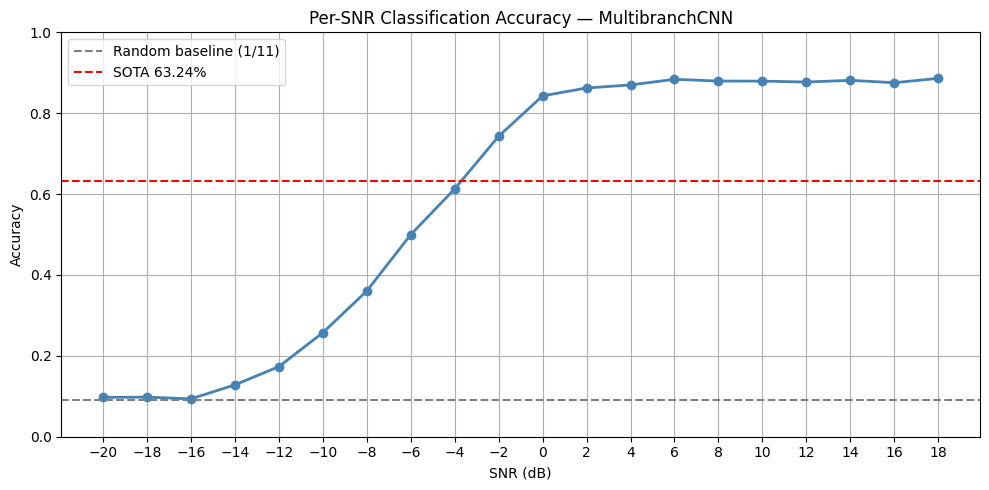

In [10]:
custom_objs = {
    'fft_features': fft_features,
    'envelope_features': envelope_features
}

model = tf.keras.models.load_model('/content/drive/MyDrive/collab/best_model.keras', custom_objects=custom_objs)

snr_acc = {}
for snr in sorted(set(snr_test)):
    mask = snr_test == snr
    preds = model.predict(X_test[mask], verbose=0)
    correct = np.argmax(preds, axis=1) == np.argmax(Y_test[mask], axis=1)
    snr_acc[snr] = correct.mean()

plt.figure(figsize=(10, 5))
plt.plot(list(snr_acc.keys()), list(snr_acc.values()), marker='o', linewidth=2, color='steelblue')
plt.axhline(1/11, color='gray', linestyle='--', label='Random baseline (1/11)')
plt.axhline(0.6324, color='red', linestyle='--', label='SOTA 63.24%')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy')
plt.title('Per-SNR Classification Accuracy — MultibranchCNN')
plt.xticks(list(snr_acc.keys()))
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/collab/snr_accuracy.png', dpi=150)
plt.show()